# ASVspoof 2019 LA Dataset Notebook Index

This notebook explains and explores the ASVspoof 2019 Logical Access dataset.

## 1. Dataset Meaning

ASVspoof 2019 is a speech dataset used for detecting fake or spoofed voices.

It contains two main types of audio:

- bonafide: real human voice
- spoof: fake or synthetic voice

The main purpose of this dataset is to train and test a model that can detect whether an audio sample is real or fake.

## 2. What is Logical Access?

LA means Logical Access.

Logical Access attacks are fake voices created using software methods.

Examples:

- Text-to-Speech: computer-generated speech from text
- Voice Conversion: changing one person's voice to sound like another person

## 3. Meaning of Labels

### bonafide

Bonafide means genuine or real speech.

This audio is spoken by a real human speaker.

### spoof

Spoof means fake or attacked speech.

This audio is created or modified using a spoofing method such as text-to-speech or voice conversion.

## 4. Dataset Splits

The dataset is divided into three main parts:

### Training Set

The training set is used to teach the model.

The model learns patterns from this data.

### Development Set

The development set is used to test and improve the model during development.

It helps us tune the model before final testing.

### Evaluation Set

The evaluation set is used for final testing.

It checks how well the model performs on unseen data.

## 5. Protocol Files

The protocol files contain information about each audio file.

They tell us:

- speaker ID
- audio file ID
- spoofing system ID
- attack type
- label

The label tells us whether the audio is bonafide or spoof.

## 6. Audio Files

The actual voice recordings are stored as `.flac` files.

The protocol file gives the audio ID, and we use this ID to find the matching audio file.

## 7. EDA Goals

In this notebook, we will explore:

- dataset folder structure
- number of samples
- train, development, and evaluation splits
- bonafide vs spoof distribution
- speaker distribution
- attack type distribution
- spoofing system distribution
- audio file availability
- useful graphs for dataset understanding

# Libraries

In [ ]:
import sys
import os

# ── Colab detection ───────────────────────────────────────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/ASVspoof2019/notebooks')
    print('Running on Google Colab | Drive mounted | Working dir set.')
except ImportError:
    IN_COLAB = False
    print('Running locally.')

## Important Terms

| Term | Meaning |
|---|---|
| ASV | Automatic Speaker Verification |
| Spoofing | Trying to fool a speaker verification system |
| Bonafide | Real human voice |
| Spoof | Fake or synthetic voice |
| LA | Logical Access |
| TTS | Text-to-Speech |
| VC | Voice Conversion |
| Train | Data used to train the model |
| Development | Data used to validate and improve the model |
| Evaluation | Data used for final testing |
| Protocol File | File that contains labels and metadata |
| FLAC | Audio file format used in this dataset |

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Folder PAth

In [7]:
DATASET_PATH = "../data/raw/LA"
# Main folders
TRAIN_FOLDER = f"{DATASET_PATH}/ASVspoof2019_LA_train"
DEV_FOLDER = f"{DATASET_PATH}/ASVspoof2019_LA_dev"
EVAL_FOLDER = f"{DATASET_PATH}/ASVspoof2019_LA_eval"
PROTOCOL_FOLDER = f"{DATASET_PATH}/ASVspoof2019_LA_cm_protocols"

# Audio folders
TRAIN_AUDIO_FOLDER = f"{TRAIN_FOLDER}/flac"
DEV_AUDIO_FOLDER = f"{DEV_FOLDER}/flac"
EVAL_AUDIO_FOLDER = f"{EVAL_FOLDER}/flac"

# Protocol files
TRAIN_PROTOCOL = f"{PROTOCOL_FOLDER}/ASVspoof2019.LA.cm.train.trn.txt"
DEV_PROTOCOL = f"{PROTOCOL_FOLDER}/ASVspoof2019.LA.cm.dev.trl.txt"
EVAL_PROTOCOL = f"{PROTOCOL_FOLDER}/ASVspoof2019.LA.cm.eval.trl.txt"
# Check if paths exist
paths = {
    "Dataset": DATASET_PATH,
    "Train Folder": TRAIN_FOLDER,
    "Dev Folder": DEV_FOLDER,
    "Eval Folder": EVAL_FOLDER,
    "Protocol Folder": PROTOCOL_FOLDER,
    "Train Audio": TRAIN_AUDIO_FOLDER,
    "Dev Audio": DEV_AUDIO_FOLDER,
    "Eval Audio": EVAL_AUDIO_FOLDER,
    "Train Protocol": TRAIN_PROTOCOL,
    "Dev Protocol": DEV_PROTOCOL,
    "Eval Protocol": EVAL_PROTOCOL,
}

for name, path in paths.items():
    print(f"{name}: {os.path.exists(path)}")

Dataset: True
Train Folder: True
Dev Folder: True
Eval Folder: True
Protocol Folder: True
Train Audio: True
Dev Audio: True
Eval Audio: True
Train Protocol: True
Dev Protocol: True
Eval Protocol: True


In [8]:
def find_protocol_file(protocol_folder, split_name):
    for file_name in os.listdir(protocol_folder):
        lower_name = file_name.lower()
        
        if split_name in lower_name and file_name.endswith(".txt"):
            return os.path.join(protocol_folder, file_name)
    
    raise FileNotFoundError(f"No protocol file found for: {split_name}")


def load_protocol_auto(protocol_folder, split_name):
    protocol_file = find_protocol_file(protocol_folder, split_name)

    df = pd.read_csv(
        protocol_file,
        sep=r"\s+",
        header=None
    )

    df.columns = [f"column_{i+1}" for i in range(df.shape[1])]

    return df, protocol_file

In [9]:
train_df, train_protocol = load_protocol_auto(PROTOCOL_FOLDER, "train")
dev_df, dev_protocol = load_protocol_auto(PROTOCOL_FOLDER, "dev")
eval_df, eval_protocol = load_protocol_auto(PROTOCOL_FOLDER, "eval")

print("Train:", train_df.shape)
print("Development:", dev_df.shape)
print("Evaluation:", eval_df.shape)
print("Train protocol:", train_protocol)
print("Dev protocol:", dev_protocol)
print("Eval protocol:", eval_protocol)
train_df.head()

Train: (25380, 5)
Development: (24844, 5)
Evaluation: (71237, 5)
Train protocol: ../data/raw/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
Dev protocol: ../data/raw/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
Eval protocol: ../data/raw/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt


,column_1,column_2,column_3,column_4,column_5
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide


## Understanding the Protocol File Columns

Before renaming the columns, we first inspect the protocol file.

The protocol file does not include column names, so Pandas loads them as:

- column_1
- column_2
- column_3
- column_4
- column_5

After checking the values, we can understand that:

- column_1 contains the speaker ID
- column_2 contains the audio file ID
- column_3 contains the spoofing system ID
- column_4 contains the attack type
- column_5 contains the label

The label tells us whether the audio is real or fake:

- bonafide = real voice
- spoof = fake voice

For real voice samples, the spoofing system and attack type are shown as `-` because no attack was used.

In [10]:
print("Sample rows from training protocol:")
display(train_df.head())

print("Unique labels:")
print(train_df["column_5"].unique())

print("\nSample bonafide rows:")
display(train_df[train_df["column_5"] == "bonafide"].head())

print("\nSample spoof rows:")
display(train_df[train_df["column_5"] == "spoof"].head())

Sample rows from training protocol:


,column_1,column_2,column_3,column_4,column_5
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide


Unique labels:
<StringArray>
['bonafide', 'spoof']
Length: 2, dtype: str

Sample bonafide rows:


,column_1,column_2,column_3,column_4,column_5
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide



Sample spoof rows:


,column_1,column_2,column_3,column_4,column_5
2580,LA_0079,LA_T_1004644,-,A01,spoof
2581,LA_0079,LA_T_1056709,-,A01,spoof
2582,LA_0079,LA_T_1195221,-,A01,spoof
2583,LA_0079,LA_T_1265032,-,A01,spoof
2584,LA_0079,LA_T_1287124,-,A01,spoof


## Rename Protocol Columns

After understanding the column meanings, we rename them to make the dataset easier to read and analyze.

In [11]:
column_names = {
    "column_1": "speaker_id",
    "column_2": "audio_id",
    "column_3": "system_id",
    "column_4": "attack_type",
    "column_5": "label"
}

train_df = train_df.rename(columns=column_names)
dev_df = dev_df.rename(columns=column_names)
eval_df = eval_df.rename(columns=column_names)

train_df.head()

,speaker_id,audio_id,system_id,attack_type,label
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide


## Dataset Size Summary

In this step, we check how many samples are available in each dataset split.

The dataset has three splits:

- Train: used to train the model
- Development: used for validation and improvement
- Evaluation: used for final testing

In [12]:
dataset_size = pd.DataFrame({
    "Split": ["Train", "Development", "Evaluation"],
    "Total Samples": [len(train_df), len(dev_df), len(eval_df)]
})

dataset_size

,Split,Total Samples
0,Train,25380
1,Development,24844
2,Evaluation,71237


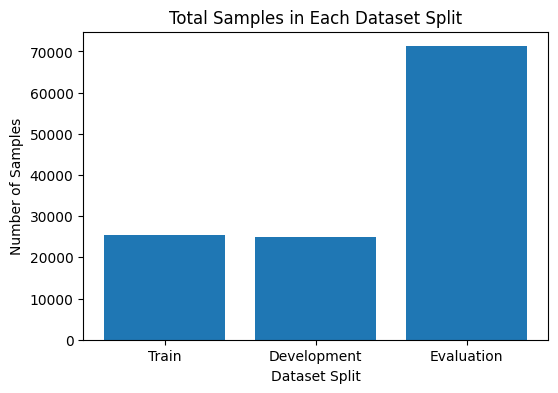

In [13]:
plt.figure(figsize=(6, 4))
plt.bar(dataset_size["Split"], dataset_size["Total Samples"])

plt.title("Total Samples in Each Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.show()

## Label Distribution

Now we check how many real and fake audio samples exist in each split.

The label column has two values:

- bonafide: real human voice
- spoof: fake or synthetic voice

In [14]:
label_distribution = pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Development": dev_df["label"].value_counts(),
    "Evaluation": eval_df["label"].value_counts()
}).fillna(0).astype(int)

label_distribution

,Train,Development,Evaluation
label,,,
spoof,22800,22296,63882
bonafide,2580,2548,7355


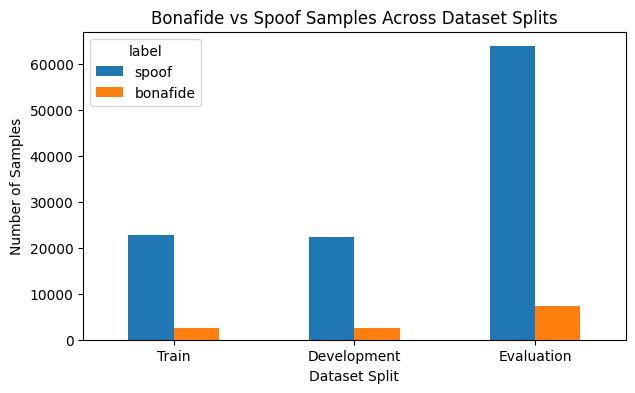

In [15]:
label_distribution.T.plot(kind="bar", figsize=(7, 4))

plt.title("Bonafide vs Spoof Samples Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

## Label Percentage

Here we calculate the percentage of real and fake samples in each split.

This helps us understand whether the dataset is balanced or imbalanced.

In [16]:
label_percentage = label_distribution.copy()

for col in label_percentage.columns:
    label_percentage[col] = (label_percentage[col] / label_percentage[col].sum()) * 100

label_percentage.round(2)

,Train,Development,Evaluation
label,,,
spoof,89.83,89.74,89.68
bonafide,10.17,10.26,10.32


## Speaker Distribution

Here we count the number of unique speakers in each split.

This helps us understand how many different people are included in train, development, and evaluation data.

In [17]:
speaker_summary = pd.DataFrame({
    "Split": ["Train", "Development", "Evaluation"],
    "Unique Speakers": [
        train_df["speaker_id"].nunique(),
        dev_df["speaker_id"].nunique(),
        eval_df["speaker_id"].nunique()
    ]
})

speaker_summary

,Split,Unique Speakers
0,Train,20
1,Development,20
2,Evaluation,67


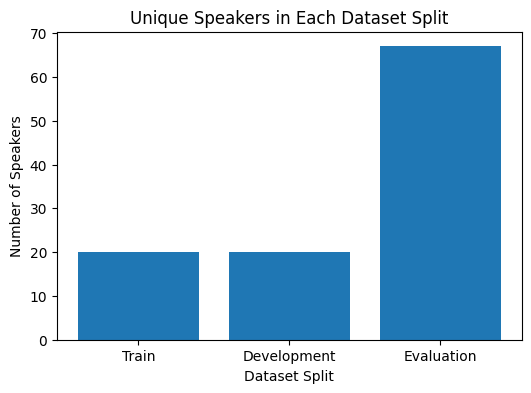

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(speaker_summary["Split"], speaker_summary["Unique Speakers"])

plt.title("Unique Speakers in Each Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Speakers")
plt.show()

## Check Speaker Overlap Between Splits

The train, development, and evaluation sets should contain different speakers.

Here we check whether any speaker appears in more than one split.

In [19]:
train_speakers = set(train_df["speaker_id"])
dev_speakers = set(dev_df["speaker_id"])
eval_speakers = set(eval_df["speaker_id"])

print("Train and Development overlap:", len(train_speakers.intersection(dev_speakers)))
print("Train and Evaluation overlap:", len(train_speakers.intersection(eval_speakers)))
print("Development and Evaluation overlap:", len(dev_speakers.intersection(eval_speakers)))

Train and Development overlap: 0
Train and Evaluation overlap: 0
Development and Evaluation overlap: 0


## Attack Type Distribution

The attack_type column shows which spoofing attack was used.

For bonafide samples, the attack type is `-` because real speech has no spoofing attack.

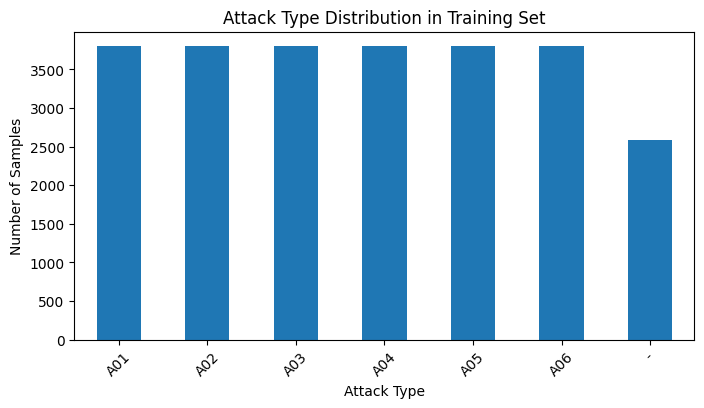

In [20]:
train_df["attack_type"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Attack Type Distribution in Training Set")
plt.xlabel("Attack Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

## Spoofing System Distribution

The system_id column shows the system used to generate the audio.

For bonafide samples, system_id is `-`.

For spoof samples, system_id shows the spoofing system.

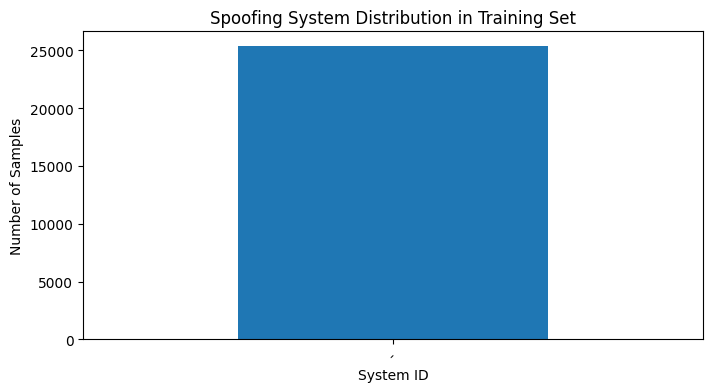

In [21]:
train_df["system_id"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Spoofing System Distribution in Training Set")
plt.xlabel("System ID")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

## Missing Values

Here we check whether any column contains missing values.

Missing values can create problems during analysis or model training.

In [22]:
print("Train missing values:")
print(train_df.isnull().sum())

print("\nDevelopment missing values:")
print(dev_df.isnull().sum())

print("\nEvaluation missing values:")
print(eval_df.isnull().sum())

Train missing values:
speaker_id     0
audio_id       0
system_id      0
attack_type    0
label          0
dtype: int64

Development missing values:
speaker_id     0
audio_id       0
system_id      0
attack_type    0
label          0
dtype: int64

Evaluation missing values:
speaker_id     0
audio_id       0
system_id      0
attack_type    0
label          0
dtype: int64


## Add Audio File Paths

The protocol file contains audio IDs, but not the full audio file path.

Here we create a new column called audio_path to connect each row with its actual `.flac` audio file.

In [23]:
train_df["audio_path"] = train_df["audio_id"].apply(lambda x: f"{TRAIN_AUDIO_FOLDER}/{x}.flac")
dev_df["audio_path"] = dev_df["audio_id"].apply(lambda x: f"{DEV_AUDIO_FOLDER}/{x}.flac")
eval_df["audio_path"] = eval_df["audio_id"].apply(lambda x: f"{EVAL_AUDIO_FOLDER}/{x}.flac")

In [24]:
train_df[["audio_id", "label", "audio_path"]].head()

,audio_id,label,audio_path
0,LA_T_1138215,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...
1,LA_T_1271820,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...
2,LA_T_1272637,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...
3,LA_T_1276960,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...
4,LA_T_1341447,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...


## Check Audio Files Exist

Here we check whether the audio files mentioned in the protocol file actually exist in the audio folder.

In [25]:
def count_flac_files(folder):
    return len([file for file in os.listdir(folder) if file.endswith(".flac")])

audio_check = pd.DataFrame({
    "Split": ["Train", "Development", "Evaluation"],
    "Protocol Rows": [len(train_df), len(dev_df), len(eval_df)],
    "Audio Files": [
        count_flac_files(TRAIN_AUDIO_FOLDER),
        count_flac_files(DEV_AUDIO_FOLDER),
        count_flac_files(EVAL_AUDIO_FOLDER)
    ]
})

audio_check

,Split,Protocol Rows,Audio Files
0,Train,25380,25380
1,Development,24844,24986
2,Evaluation,71237,71933


## EDA Summary So Far

In this EDA, we checked:

- Total samples in each split
- Bonafide and spoof label distribution
- Label percentage
- Number of unique speakers
- Speaker overlap between splits
- Attack type distribution
- Spoofing system distribution
- Missing values
- Audio file path matching

This gives us a clear understanding of the dataset structure before audio-level analysis.

# Visual EDA

In this section, we use graphs to understand the ASVspoof 2019 LA dataset.

The focus is on:

- Number of samples in each split
- Real vs fake voice distribution
- Speaker distribution
- Attack type distribution
- Spoofing system distribution
- Class imbalance

In [26]:
# Create copies of each split
train_plot_df = train_df.copy()
dev_plot_df = dev_df.copy()
eval_plot_df = eval_df.copy()

# Add split name
train_plot_df["split"] = "Train"
dev_plot_df["split"] = "Development"
eval_plot_df["split"] = "Evaluation"

# Combine all splits
all_df = pd.concat(
    [train_plot_df, dev_plot_df, eval_plot_df],
    ignore_index=True
)

all_df.head()

,speaker_id,audio_id,system_id,attack_type,label,audio_path,split
0,LA_0079,LA_T_1138215,-,-,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...,Train
1,LA_0079,LA_T_1271820,-,-,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...,Train
2,LA_0079,LA_T_1272637,-,-,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...,Train
3,LA_0079,LA_T_1276960,-,-,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...,Train
4,LA_0079,LA_T_1341447,-,-,bonafide,../data/raw/LA/ASVspoof2019_LA_train/flac/LA_T...,Train


## Graph 2: Bonafide vs Spoof Samples

This graph shows how many real and fake samples are present in the full dataset.

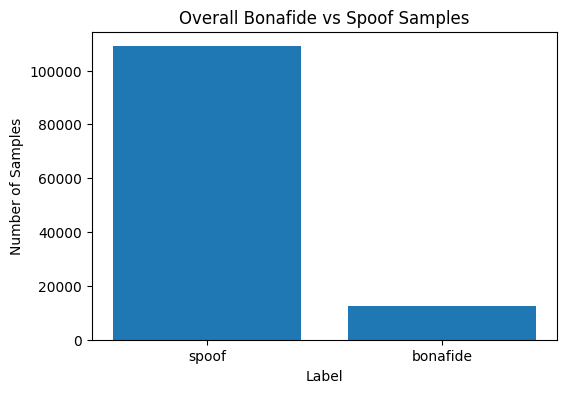

In [27]:
label_counts = all_df["label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)

plt.title("Overall Bonafide vs Spoof Samples")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.show()

## Graph : Bonafide vs Spoof Pie Chart

This pie chart shows the share of real and fake audio samples in the full dataset.

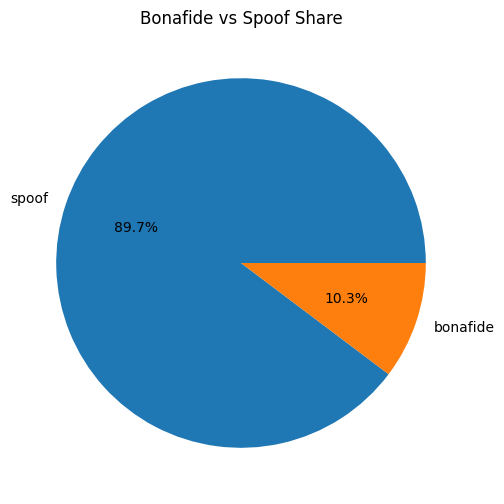

In [28]:
plt.figure(figsize=(6, 6))
plt.pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%")

plt.title("Bonafide vs Spoof Share")
plt.show()